# Customer Churn Prediction
## Group 4 – Machine Learning

### Final Model Comparison and Selection

This notebook consolidates the machine learning work completed by Group 4.

Four classification model families were developed and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

Models were compared using consistent cross-validation metrics, with particular emphasis on Precision, Recall, F1-score and ROC-AUC because the business objective is to identify customers genuinely at risk of churn.

After comparing the candidate models, Tuned Logistic Regression was selected as the final model based on its overall balance of churn detection performance, cross-validation F1-score, generalization and deployment simplicity.

In [80]:
# ==========================================
# 1. Imports and Configuration
# ==========================================

from pathlib import Path

import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

import matplotlib.pyplot as plt

RANDOM_STATE = 42
TEST_SIZE = 0.20

In [81]:
# ==========================================
# 2. Locate Project Root
# ==========================================

DATA_RELATIVE_PATH = (
    Path("Feature Engineering & Statistical Analysis")
    / "outputs"
    / "customer_churn_feature_engineered.csv"
)


def find_project_root(start_path=None):
    current = Path(
        start_path or Path.cwd()
    ).resolve()

    for candidate in [
        current,
        *current.parents
    ]:
        if (
            candidate
            / DATA_RELATIVE_PATH
        ).exists():
            return candidate

    raise FileNotFoundError(
        "Project root could not be located."
    )


PROJECT_ROOT = find_project_root()

DATA_PATH = (
    PROJECT_ROOT
    / DATA_RELATIVE_PATH
)

ML_DIR = (
    PROJECT_ROOT
    / "Machine Learning"
)

MODELS_DIR = ML_DIR / "models"
OUTPUTS_DIR = ML_DIR / "outputs"
FIGURES_DIR = ML_DIR / "figures"

print("Project root:")
print(PROJECT_ROOT)

Project root:
D:\Internship Tasks\Group Task - Customer Churn Prediction & Business Intelligence System\Customer-Churn-Prediction-Business-Intelligence-System


In [82]:
# ==========================================
# 3. Final Cross-Validation Model Comparison
# ==========================================

model_comparison = pd.DataFrame([
    {
        "Model": "Tuned Logistic Regression",
        "Accuracy": 0.7622,
        "Precision": 0.5341,
        "Recall": 0.8134,
        "F1-score": 0.6446,
        "ROC-AUC": 0.8596
    },
    {
        "Model": "Weighted XGBoost",
        "Accuracy": 0.7568,
        "Precision": 0.5273,
        "Recall": 0.8174,
        "F1-score": 0.6409,
        "ROC-AUC": 0.8634
    },
    {
        "Model": "Tuned XGBoost",
        "Accuracy": 0.8136,
        "Precision": 0.6776,
        "Recall": 0.5692,
        "F1-score": 0.6184,
        "ROC-AUC": 0.8632
    },
    {
        "Model": "Tuned Decision Tree",
        "Accuracy": 0.7969,
        "Precision": 0.6300,
        "Recall": 0.5719,
        "F1-score": 0.5955,
        "ROC-AUC": 0.8321
    },
    {
        "Model": "Tuned Random Forest",
        "Accuracy": 0.8039,
        "Precision": 0.6661,
        "Recall": 0.5251,
        "F1-score": 0.5869,
        "ROC-AUC": 0.8579
    }
])

model_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Tuned Logistic Regression,0.7622,0.5341,0.8134,0.6446,0.8596
1,Weighted XGBoost,0.7568,0.5273,0.8174,0.6409,0.8634
2,Tuned XGBoost,0.8136,0.6776,0.5692,0.6184,0.8632
3,Tuned Decision Tree,0.7969,0.6300,0.5719,0.5955,0.8321
4,Tuned Random Forest,0.8039,0.6661,0.5251,0.5869,0.8579


In [83]:
# ==========================================
# 4. Rank Models by F1-score
# ==========================================

model_comparison_ranked = (
    model_comparison
    .sort_values(
        by="F1-score",
        ascending=False
    )
    .reset_index(drop=True)
)

model_comparison_ranked.insert(
    0,
    "F1 Rank",
    range(
        1,
        len(model_comparison_ranked) + 1
    )
)

model_comparison_ranked

,F1 Rank,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,1,Tuned Logistic Regression,0.7622,0.5341,0.8134,0.6446,0.8596
1,2,Weighted XGBoost,0.7568,0.5273,0.8174,0.6409,0.8634
2,3,Tuned XGBoost,0.8136,0.6776,0.5692,0.6184,0.8632
3,4,Tuned Decision Tree,0.7969,0.6300,0.5719,0.5955,0.8321
4,5,Tuned Random Forest,0.8039,0.6661,0.5251,0.5869,0.8579


In [84]:
# ==========================================
# 5. Final Model Selection
# ==========================================

FINAL_MODEL_NAME = (
    "Tuned Logistic Regression"
)

print("=" * 60)
print("FINAL GROUP 4 MODEL SELECTION")
print("=" * 60)

print(
    "Selected model:",
    FINAL_MODEL_NAME
)

print()
print(
    "Reason:"
)

print(
    "- Highest cross-validation F1-score"
)

print(
    "- High churn Recall"
)

print(
    "- Strong ROC-AUC"
)

print(
    "- Good Precision/Recall balance"
)

print(
    "- Strong generalization"
)

print(
    "- Simple interpretation and deployment"
)

print("=" * 60)

FINAL GROUP 4 MODEL SELECTION
Selected model: Tuned Logistic Regression

Reason:
- Highest cross-validation F1-score
- High churn Recall
- Strong ROC-AUC
- Good Precision/Recall balance
- Strong generalization
- Simple interpretation and deployment


In [85]:
# ==========================================
# 6. Save Final Model Comparison
# ==========================================

OUTPUTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_COMPARISON_PATH = (
    OUTPUTS_DIR
    / "model_comparison.csv"
)

model_comparison_ranked.to_csv(
    MODEL_COMPARISON_PATH,
    index=False
)

print(
    "Model comparison saved:"
)

print(MODEL_COMPARISON_PATH)

Model comparison saved:
D:\Internship Tasks\Group Task - Customer Churn Prediction & Business Intelligence System\Customer-Churn-Prediction-Business-Intelligence-System\Machine Learning\outputs\model_comparison.csv


### Final Model Selection Interpretation

Tuned Logistic Regression achieved the highest cross-validation F1-score among the compared model candidates while maintaining high Recall and strong ROC-AUC.

Weighted XGBoost achieved slightly higher Recall and ROC-AUC, but the difference was small and came with slightly lower Precision and F1-score.

Because the business objective requires identifying churn customers while maintaining a reasonable balance between missed churners and false retention alerts, Tuned Logistic Regression was selected as the final model.

The final model selection was based on cross-validation performance rather than the held-out test set.

## 4. Final Held-Out Test Evaluation

The final model was selected using cross-validation results only.

After locking the model choice, the held-out 20% test set is now used for the first final unbiased evaluation.

The same dataset, 21 core features, stratified split and random state used during model development are reproduced to ensure that the final test set is identical to the one reserved earlier.

In [86]:
# ==========================================
# 7. Load Final Modelling Dataset
# ==========================================

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Rows   :", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully.
Rows   : 7043
Columns: 29


In [87]:
# ==========================================
# 8. Define Final Feature Set and Target
# ==========================================

TARGET = "Churn Value"

CORE_FEATURES = [
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Tenure Months",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method",
    "Monthly Charges",
    "Total Charges",
    "Fiber_Monthly_Risk",
    "New_High_Spend",
    "New_Monthly_Customer",
    "Security_Tech_Bundle"
]

missing_features = [
    feature
    for feature in CORE_FEATURES
    if feature not in df.columns
]

if missing_features:
    raise ValueError(
        f"Missing required features: {missing_features}"
    )

if TARGET not in df.columns:
    raise ValueError(
        f"Target '{TARGET}' was not found."
    )

X = df[CORE_FEATURES].copy()
y = df[TARGET].copy()

print("Feature count:", len(CORE_FEATURES))
print("X shape      :", X.shape)
print("y shape      :", y.shape)

Feature count: 21
X shape      : (7043, 21)
y shape      : (7043,)


In [88]:
# ==========================================
# 9. Reproduce Held-Out Train/Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows    :", len(X_test))

print(
    "Training churn (%):",
    round(y_train.mean() * 100, 2)
)

print(
    "Test churn (%)    :",
    round(y_test.mean() * 100, 2)
)

Training rows: 5634
Test rows    : 1409
Training churn (%): 26.54
Test churn (%)    : 26.54


In [89]:
# ==========================================
# 10. Verify Held-Out Split Integrity
# ==========================================

overlap = set(
    X_train.index
).intersection(
    X_test.index
)

if overlap:
    raise ValueError(
        "Train/test overlap detected."
    )

if (
    len(X_train)
    + len(X_test)
    != len(X)
):
    raise ValueError(
        "Train/test row counts are invalid."
    )

print("Train/test overlap:", len(overlap))
print("Split integrity check passed.")

Train/test overlap: 0
Split integrity check passed.


In [90]:
# ==========================================
# 11. Load Selected Final Model
# ==========================================

SELECTED_MODEL_PATH = (
    MODELS_DIR
    / "logistic_regression.joblib"
)

if not SELECTED_MODEL_PATH.exists():
    raise FileNotFoundError(
        "Selected Logistic Regression model "
        "could not be found."
    )

final_model = joblib.load(
    SELECTED_MODEL_PATH
)

print("Selected model loaded successfully.")
print("Model:", FINAL_MODEL_NAME)
print("Path :", SELECTED_MODEL_PATH)

Selected model loaded successfully.
Model: Tuned Logistic Regression
Path : D:\Internship Tasks\Group Task - Customer Churn Prediction & Business Intelligence System\Customer-Churn-Prediction-Business-Intelligence-System\Machine Learning\models\logistic_regression.joblib


In [91]:
# ==========================================
# 12. Generate Final Test Predictions
# ==========================================

y_test_pred = final_model.predict(
    X_test
)

y_test_prob = final_model.predict_proba(
    X_test
)[:, 1]

print("Predictions generated:", len(y_test_pred))
print("Probabilities generated:", len(y_test_prob))

Predictions generated: 1409
Probabilities generated: 1409


In [92]:
# ==========================================
# 13. Validate Test Prediction Output
# ==========================================

if len(y_test_pred) != len(y_test):
    raise ValueError(
        "Prediction row count does not match test set."
    )

if not np.all(
    (y_test_prob >= 0)
    & (y_test_prob <= 1)
):
    raise ValueError(
        "Invalid prediction probabilities detected."
    )

print(
    "Prediction count validation passed."
)

print(
    "Probability range:",
    round(y_test_prob.min(), 4),
    "to",
    round(y_test_prob.max(), 4)
)

Prediction count validation passed.
Probability range: 0.003 to 0.9599


In [93]:
# ==========================================
# 14. Final Held-Out Test Metrics
# ==========================================

final_test_metrics = pd.DataFrame([
    {
        "Model": FINAL_MODEL_NAME,

        "Accuracy":
            accuracy_score(
                y_test,
                y_test_pred
            ),

        "Precision":
            precision_score(
                y_test,
                y_test_pred
            ),

        "Recall":
            recall_score(
                y_test,
                y_test_pred
            ),

        "F1-score":
            f1_score(
                y_test,
                y_test_pred
            ),

        "ROC-AUC":
            roc_auc_score(
                y_test,
                y_test_prob
            )
    }
])

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

final_test_metrics[
    metric_columns
] = (
    final_test_metrics[
        metric_columns
    ]
    .round(4)
)

final_test_metrics

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Tuned Logistic Regression,0.7495,0.5185,0.7861,0.6249,0.8487


In [94]:
# ==========================================
# 15. Final Test Confusion Matrix
# ==========================================

final_confusion_matrix = confusion_matrix(
    y_test,
    y_test_pred
)

tn, fp, fn, tp = (
    final_confusion_matrix.ravel()
)

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print(
    "\nTotal:",
    tn + fp + fn + tp
)

assert (
    tn + fp + fn + tp
    == len(y_test)
)

print(
    "\nConfusion matrix integrity passed."
)

True Negatives : 762
False Positives: 273
False Negatives: 80
True Positives : 294

Total: 1409

Confusion matrix integrity passed.


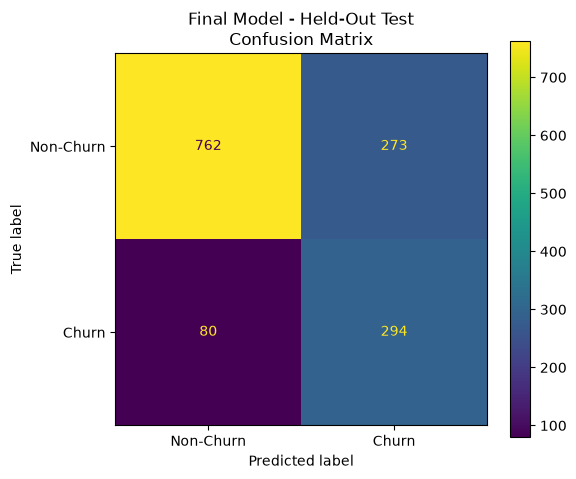

Final confusion matrix saved:
D:\Internship Tasks\Group Task - Customer Churn Prediction & Business Intelligence System\Customer-Churn-Prediction-Business-Intelligence-System\Machine Learning\figures\confusion_matrix_final_logistic_regression.png


In [95]:
# ==========================================
# 16. Plot Final Test Confusion Matrix
# ==========================================

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay(
    confusion_matrix=final_confusion_matrix,
    display_labels=[
        "Non-Churn",
        "Churn"
    ]
).plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    "Final Model - Held-Out Test\n"
    "Confusion Matrix"
)

plt.tight_layout()

FINAL_CM_PATH = (
    FIGURES_DIR
    / "confusion_matrix_final_logistic_regression.png"
)

plt.savefig(
    FINAL_CM_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Final confusion matrix saved:"
)

print(FINAL_CM_PATH)

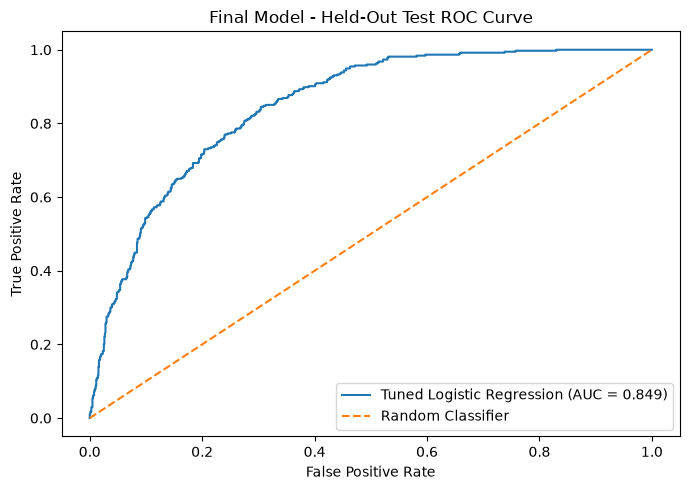

Final ROC curve saved:
D:\Internship Tasks\Group Task - Customer Churn Prediction & Business Intelligence System\Customer-Churn-Prediction-Business-Intelligence-System\Machine Learning\figures\roc_curve_final_logistic_regression.png


In [96]:
# ==========================================
# 17. Final Test ROC Curve
# ==========================================

final_fpr, final_tpr, _ = roc_curve(
    y_test,
    y_test_prob
)

final_roc_auc = roc_auc_score(
    y_test,
    y_test_prob
)

fig, ax = plt.subplots(
    figsize=(7, 5)
)

ax.plot(
    final_fpr,
    final_tpr,
    label=(
        f"Tuned Logistic Regression "
        f"(AUC = {final_roc_auc:.3f})"
    )
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.set_title(
    "Final Model - Held-Out Test ROC Curve"
)

ax.legend()

plt.tight_layout()

FINAL_ROC_PATH = (
    FIGURES_DIR
    / "roc_curve_final_logistic_regression.png"
)

plt.savefig(
    FINAL_ROC_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Final ROC curve saved:"
)

print(FINAL_ROC_PATH)

In [97]:
# ==========================================
# 18. CV vs Held-Out Test Comparison
# ==========================================

selected_cv_row = (
    model_comparison[
        model_comparison["Model"]
        == "Tuned Logistic Regression"
    ]
    .iloc[0]
)

cv_vs_test = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Cross-Validation": [
        selected_cv_row["Accuracy"],
        selected_cv_row["Precision"],
        selected_cv_row["Recall"],
        selected_cv_row["F1-score"],
        selected_cv_row["ROC-AUC"]
    ],

    "Held-Out Test": [
        final_test_metrics.loc[
            0, "Accuracy"
        ],
        final_test_metrics.loc[
            0, "Precision"
        ],
        final_test_metrics.loc[
            0, "Recall"
        ],
        final_test_metrics.loc[
            0, "F1-score"
        ],
        final_test_metrics.loc[
            0, "ROC-AUC"
        ]
    ]
})

cv_vs_test[
    "Difference"
] = (
    cv_vs_test[
        "Held-Out Test"
    ]
    - cv_vs_test[
        "Cross-Validation"
    ]
)

cv_vs_test[
    [
        "Cross-Validation",
        "Held-Out Test",
        "Difference"
    ]
] = (
    cv_vs_test[
        [
            "Cross-Validation",
            "Held-Out Test",
            "Difference"
        ]
    ]
    .round(4)
)

cv_vs_test

,Metric,Cross-Validation,Held-Out Test,Difference
0,Accuracy,0.7622,0.7495,-0.0127
1,Precision,0.5341,0.5185,-0.0156
2,Recall,0.8134,0.7861,-0.0273
3,F1-score,0.6446,0.6249,-0.0197
4,ROC-AUC,0.8596,0.8487,-0.0109


### Final Test Evaluation Interpretation

The Tuned Logistic Regression model was evaluated on the held-out test set only after the final model had been selected using cross-validation.

The test results remain reasonably consistent with the cross-validation results, indicating that the model generalizes to previously unseen customers.

Recall remains a particularly important metric for this churn application because false negatives represent customers who actually churn but are not identified by the model.

The model maintains strong churn-detection capability and ROC-AUC performance on the held-out test data while providing a reasonable balance between Precision and Recall.

No additional hyperparameter tuning or model-selection decisions are made using the test-set results.

## 5. Final Deployment Pipeline

After completing the unbiased held-out test evaluation, the selected Logistic Regression pipeline is refitted using the complete available modelling dataset.

This refitted pipeline is intended for deployment and downstream prediction use.

The previously recorded held-out test results remain the unbiased estimate of model generalization. Predictions generated after refitting on the full dataset are operational churn-risk scores and are not used as test-set performance measurements.

In [98]:
# ==========================================
# 19. Deployment Pipeline Import
# ==========================================

from sklearn.base import clone

In [99]:
# ==========================================
# 20. Create Final Deployment Pipeline
# ==========================================

final_deployment_pipeline = clone(
    final_model
)

print(
    "Fresh deployment pipeline created."
)

Fresh deployment pipeline created.


In [100]:
# ==========================================
# 21. Refit Final Pipeline on Full Dataset
# ==========================================

final_deployment_pipeline.fit(
    X,
    y
)

print(
    "Final deployment pipeline fitted "
    "on the complete dataset."
)

print(
    "Training rows used:",
    len(X)
)

Final deployment pipeline fitted on the complete dataset.
Training rows used: 7043


d:\Internship Tasks\Group Task - Customer Churn Prediction & Business Intelligence System\Customer-Churn-Prediction-Business-Intelligence-System\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Internship Tasks\Group Task - Customer Churn Prediction & Business Intelligence System\Customer-Churn-Prediction-Business-Intelligence-System\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [101]:
# ==========================================
# 22. Save Final Churn Pipeline
# ==========================================

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FINAL_PIPELINE_PATH = (
    MODELS_DIR
    / "final_churn_pipeline.joblib"
)

joblib.dump(
    final_deployment_pipeline,
    FINAL_PIPELINE_PATH
)

print(
    "Final churn pipeline saved:"
)

print(FINAL_PIPELINE_PATH)

Final churn pipeline saved:
D:\Internship Tasks\Group Task - Customer Churn Prediction & Business Intelligence System\Customer-Churn-Prediction-Business-Intelligence-System\Machine Learning\models\final_churn_pipeline.joblib


In [102]:
# ==========================================
# 23. Reload Final Churn Pipeline
# ==========================================

loaded_final_pipeline = joblib.load(
    FINAL_PIPELINE_PATH
)

print(
    "Final churn pipeline reloaded successfully."
)

Final churn pipeline reloaded successfully.


In [103]:
# ==========================================
# 24. Verify Final Pipeline Serialization
# ==========================================

verification_sample = X.iloc[:10]

before_save_predictions = (
    final_deployment_pipeline.predict(
        verification_sample
    )
)

after_load_predictions = (
    loaded_final_pipeline.predict(
        verification_sample
    )
)

before_save_probabilities = (
    final_deployment_pipeline.predict_proba(
        verification_sample
    )[:, 1]
)

after_load_probabilities = (
    loaded_final_pipeline.predict_proba(
        verification_sample
    )[:, 1]
)

class_predictions_match = np.array_equal(
    before_save_predictions,
    after_load_predictions
)

probabilities_match = np.allclose(
    before_save_probabilities,
    after_load_probabilities
)

print(
    "Class predictions match:",
    class_predictions_match
)

print(
    "Probabilities match     :",
    probabilities_match
)

if not (
    class_predictions_match
    and probabilities_match
):
    raise ValueError(
        "Final pipeline serialization "
        "verification failed."
    )

print(
    "\nFinal pipeline serialization passed."
)

Class predictions match: True
Probabilities match     : True

Final pipeline serialization passed.


In [104]:
# ==========================================
# 25. Generate Final Churn Predictions
# ==========================================

final_predicted_class = (
    loaded_final_pipeline.predict(X)
)

final_churn_probability = (
    loaded_final_pipeline
    .predict_proba(X)[:, 1]
)

print(
    "Predictions generated:",
    len(final_predicted_class)
)

print(
    "Probabilities generated:",
    len(final_churn_probability)
)

Predictions generated: 7043
Probabilities generated: 7043


In [105]:
# ==========================================
# 26. Validate Final Prediction Output
# ==========================================

if (
    len(final_predicted_class)
    != len(df)
):
    raise ValueError(
        "Prediction count does not "
        "match dataset rows."
    )

if not np.all(
    (final_churn_probability >= 0)
    & (final_churn_probability <= 1)
):
    raise ValueError(
        "Invalid churn probabilities detected."
    )

print(
    "Prediction count validation passed."
)

print(
    "Probability range:",
    round(
        final_churn_probability.min(),
        4
    ),
    "to",
    round(
        final_churn_probability.max(),
        4
    )
)

Prediction count validation passed.
Probability range: 0.002 to 0.9583


In [106]:
# ==========================================
# 27. Build Churn Prediction Output
# ==========================================

churn_predictions = pd.DataFrame({
    "row_index": df.index,

    "Actual Churn":
        y.values,

    "Predicted Churn":
        final_predicted_class,

    "Churn Probability":
        final_churn_probability
})

churn_predictions[
    "Churn Probability"
] = (
    churn_predictions[
        "Churn Probability"
    ]
    .round(6)
)

churn_predictions.head()

,row_index,Actual Churn,Predicted Churn,Churn Probability
0,0,1,1,0.641297
1,1,1,1,0.582487
2,2,1,1,0.729105
3,3,1,0,0.455835
4,4,1,0,0.310803


In [107]:
# ==========================================
# 28. Add Churn Risk Category
# ==========================================

churn_predictions[
    "Risk Category"
] = pd.cut(
    churn_predictions[
        "Churn Probability"
    ],
    bins=[
        -0.001,
        0.30,
        0.60,
        1.00
    ],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

churn_predictions[
    "Risk Category"
].value_counts()

Risk Category
Low       3187
High      2354
Medium    1502
Name: count, dtype: int64

In [108]:
# ==========================================
# 29. Save Churn Prediction Output
# ==========================================

OUTPUTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHURN_PREDICTIONS_PATH = (
    OUTPUTS_DIR
    / "churn_predictions.csv"
)

churn_predictions.to_csv(
    CHURN_PREDICTIONS_PATH,
    index=False
)

print(
    "Churn prediction output saved:"
)

print(CHURN_PREDICTIONS_PATH)

Churn prediction output saved:
D:\Internship Tasks\Group Task - Customer Churn Prediction & Business Intelligence System\Customer-Churn-Prediction-Business-Intelligence-System\Machine Learning\outputs\churn_predictions.csv


In [109]:
# ==========================================
# 30. Validate Saved Prediction Output
# ==========================================

saved_predictions = pd.read_csv(
    CHURN_PREDICTIONS_PATH
)

print(
    "Saved rows   :",
    saved_predictions.shape[0]
)

print(
    "Saved columns:",
    saved_predictions.shape[1]
)

if (
    saved_predictions.shape[0]
    != df.shape[0]
):
    raise ValueError(
        "Saved prediction row count "
        "does not match source dataset."
    )

if (
    saved_predictions[
        "Churn Probability"
    ].isna().any()
):
    raise ValueError(
        "Missing churn probabilities detected."
    )

print(
    "Prediction output validation passed."
)

Saved rows   : 7043
Saved columns: 5
Prediction output validation passed.


In [110]:
# ==========================================
# 31. Deployment Handoff Summary
# ==========================================

print("=" * 70)
print(
    "FINAL MODEL DEPLOYMENT HANDOFF"
)
print("=" * 70)

print(
    "Final model        : "
    "Tuned Logistic Regression"
)

print(
    "Deployment rows    :",
    len(X)
)

print(
    "Final pipeline     :",
    FINAL_PIPELINE_PATH.name
)

print(
    "Prediction output  :",
    CHURN_PREDICTIONS_PATH.name
)

print(
    "Probability output : VERIFIED"
)

print(
    "Risk segmentation  : "
    "Low / Medium / High"
)

print()
print(
    "Important:"
)

print(
    "Held-out test metrics were recorded "
    "before full-data refitting."
)

print(
    "Full-data predictions are operational "
    "risk scores, not test metrics."
)

print("=" * 70)
print(
    "DEPLOYMENT ARTIFACTS READY"
)
print("=" * 70)

FINAL MODEL DEPLOYMENT HANDOFF
Final model        : Tuned Logistic Regression
Deployment rows    : 7043
Final pipeline     : final_churn_pipeline.joblib
Prediction output  : churn_predictions.csv
Probability output : VERIFIED
Risk segmentation  : Low / Medium / High

Important:
Held-out test metrics were recorded before full-data refitting.
Full-data predictions are operational risk scores, not test metrics.
DEPLOYMENT ARTIFACTS READY


### Deployment Handoff Interpretation

After recording the final held-out test performance, the selected Logistic Regression pipeline was refitted using the complete available modelling dataset.

The refitted pipeline was saved as `final_churn_pipeline.joblib` for deployment and downstream use.

The saved pipeline includes the preprocessing transformations and Logistic Regression classifier, allowing new customer records to be processed and scored using a single reusable object.

Customer-level churn probabilities were generated and saved in `churn_predictions.csv`.

The probability output can support downstream interfaces, dashboards and retention analysis. The Low, Medium and High risk categories are descriptive business segments and are not presented as statistically optimized classification thresholds.

The held-out test metrics reported earlier remain the unbiased evaluation of final model generalization.